In [26]:
# ============================================================
# CÉLULA 1 - Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)



In [27]:

# ============================================================
# CÉLULA 2 - Carregar IBGE (população) e preparar tabela de
# conversão de código (SIA usa 6 dígitos, IBGE/CNES usam 7)
# ============================================================
df_ibge = pd.read_csv('Dados-Novo/ibge_populacao_sp.csv')
df_ibge_2024 = df_ibge[df_ibge['ano'] == 2024][['id_municipio', 'populacao']].copy()

# tabela de conversão: 6 primeiros dígitos -> código completo (7 dígitos)
df_ibge['cod6'] = df_ibge['id_municipio'].astype(str).str[:6]
lookup_municipio = df_ibge[['cod6', 'id_municipio']].drop_duplicates()

print("População 2024 - municípios:", df_ibge_2024.shape[0])
df_ibge_2024.head()



População 2024 - municípios: 645


,id_municipio,populacao
1935,3500105,35642
1936,3500204,4478
1937,3500303,32888
1938,3500402,7470
1939,3500501,18245


In [28]:

# ============================================================
# CÉLULA 3 - Carregar e tratar SIA (atendimentos ambulatoriais)
# ============================================================
df_sia = pd.read_csv(
    'Dados-Novo/sia_cnv_qasp113702191_243_242_4.csv',
    encoding='latin1', sep=';', skiprows=3, skipfooter=10, engine='python'
)
df_sia.columns = ['municipio_raw', 'qtd_aprovada_total']

# remove linhas de rodapé residuais (só mantém linhas que começam com código numérico)
df_sia = df_sia[df_sia['municipio_raw'].str[:1].str.isdigit()].copy()

# separa código (6 dígitos) e nome do município
df_sia['cod6'] = df_sia['municipio_raw'].str.strip().str[:6]
df_sia['nome_municipio'] = df_sia['municipio_raw'].str.strip().str[7:]

# cruza com a tabela de conversão para obter o código de 7 dígitos
df_sia = df_sia.merge(lookup_municipio, on='cod6', how='left')
df_sia_final = df_sia[['id_municipio', 'nome_municipio', 'qtd_aprovada_total']]

print("SIA - municípios com dado de atendimento:", df_sia_final.shape[0])
df_sia_final.head()



SIA - municípios com dado de atendimento: 643


,id_municipio,nome_municipio,qtd_aprovada_total
0,3500105,ADAMANTINA,2674237.0
1,3500204,ADOLFO,442088.0
2,3500303,AGUAI,2363632.0
3,3500402,AGUAS DA PRATA,329005.0
4,3500501,AGUAS DE LINDOIA,216104.0


In [29]:

# ============================================================
# CÉLULA 4 - Carregar e agregar CNES-ST (estabelecimentos), ano 2024
# ============================================================
df_cnes_st = pd.read_csv('Dados-Novo/cnes_estabelecimento_sp.csv')

cnes_st_2024 = df_cnes_st[df_cnes_st['ano'] == 2024].groupby('id_municipio').agg(
    qtd_estabelecimentos=('id_estabelecimento_cnes', 'nunique'),
    total_leitos_clinicos=('quantidade_leito_clinico', 'sum'),
    total_leitos_cirurgicos=('quantidade_leito_cirurgico', 'sum')
).reset_index()

print("CNES-ST 2024 agregado por município:", cnes_st_2024.shape[0])
cnes_st_2024.head()



CNES-ST 2024 agregado por município: 645


,id_municipio,qtd_estabelecimentos,total_leitos_clinicos,total_leitos_cirurgicos
0,3500105,175,65,15
1,3500204,5,0,0
2,3500303,72,24,0
3,3500402,6,0,0
4,3500501,49,22,4


In [30]:

# ============================================================
# CÉLULA 5 - Carregar e agregar CNES-PF (profissionais), ano 2024
# ============================================================
df_cnes_pf = pd.read_csv('Dados-Novo/cnes_profissional_sp_agg.csv')

cnes_pf_2024 = df_cnes_pf[df_cnes_pf['ano'] == 2024].groupby('id_municipio').agg(
    qtd_profissionais=('quantidade_profissionais', 'sum'),
    carga_horaria_ambulatorial_total=('soma_carga_horaria_ambulatorial', 'sum')
).reset_index()

print("CNES-PF 2024 agregado por município:", cnes_pf_2024.shape[0])
cnes_pf_2024.head()



CNES-PF 2024 agregado por município: 645


,id_municipio,qtd_profissionais,carga_horaria_ambulatorial_total
0,3500105,1011,18192
1,3500204,97,2620
2,3500303,488,11142
3,3500402,99,3031
4,3500501,283,5058


In [31]:

# ============================================================
# CÉLULA 6 - Integração final (dataset unificado)
# ============================================================
df_final = df_ibge_2024.merge(cnes_st_2024, on='id_municipio', how='left') \
                        .merge(cnes_pf_2024, on='id_municipio', how='left') \
                        .merge(df_sia_final, on='id_municipio', how='left')

print("Dataset unificado final:", df_final.shape)
print("\nValores ausentes por coluna:")
print(df_final.isna().sum())
df_final.head(10)



Dataset unificado final: (645, 9)

Valores ausentes por coluna:
id_municipio                        0
populacao                           0
qtd_estabelecimentos                0
total_leitos_clinicos               0
total_leitos_cirurgicos             0
qtd_profissionais                   0
carga_horaria_ambulatorial_total    0
nome_municipio                      2
qtd_aprovada_total                  2
dtype: int64


,id_municipio,populacao,qtd_estabelecimentos,total_leitos_clinicos,total_leitos_cirurgicos,qtd_profissionais,carga_horaria_ambulatorial_total,nome_municipio,qtd_aprovada_total
0,3500105,35642,175,65,15,1011,18192,ADAMANTINA,2674237.0
1,3500204,4478,5,0,0,97,2620,ADOLFO,442088.0
2,3500303,32888,72,24,0,488,11142,AGUAI,2363632.0
3,3500402,7470,6,0,0,99,3031,AGUAS DA PRATA,329005.0
4,3500501,18245,49,22,4,283,5058,AGUAS DE LINDOIA,216104.0
5,3500550,7407,10,0,0,115,2689,AGUAS DE SANTA BARBARA,286870.0
6,3500600,2829,5,0,0,108,1878,AGUAS DE SAO PEDRO,463257.0
7,3500709,38879,38,22,18,582,12526,AGUDOS,2679868.0
8,3500758,6330,10,0,0,95,2533,ALAMBARI,583837.0
9,3500808,4556,8,0,0,68,1953,ALFREDO MARCONDES,230455.0


In [32]:

# ============================================================
# CÉLULA 7 - Investigar os valores ausentes (documentar no AED)
# ============================================================
municipios_sem_atendimento = df_final[df_final['qtd_aprovada_total'].isna()]
print("Municípios sem registro no SIA (possível zero atendimentos):")
print(municipios_sem_atendimento[['id_municipio', 'populacao']])

# Nota para o dicionário de dados: esses municípios não aparecem no
# arquivo do SIA porque o TABNET omite linhas zeradas, não retornando
# "0" explicitamente. Trataremos como zero, já que não há indício de
# erro de cruzamento (nenhuma falha de match de código foi encontrada).
df_final['qtd_aprovada_total'] = df_final['qtd_aprovada_total'].fillna(0)



Municípios sem registro no SIA (possível zero atendimentos):
     id_municipio  populacao
505       3545100       4883
610       3554656       2063


In [33]:

# ============================================================
# CÉLULA 8 - Criar indicadores derivados (proxy de abandono)
# ============================================================
df_final['atend_per_1000_hab'] = (df_final['qtd_aprovada_total'] / df_final['populacao']) * 1000
df_final['hab_por_profissional'] = df_final['populacao'] / df_final['qtd_profissionais']
df_final['hab_por_estabelecimento'] = df_final['populacao'] / df_final['qtd_estabelecimentos']

df_final.describe()



,id_municipio,populacao,qtd_estabelecimentos,total_leitos_clinicos,total_leitos_cirurgicos,qtd_profissionais,carga_horaria_ambulatorial_total,qtd_aprovada_total,atend_per_1000_hab,hab_por_profissional,hab_por_estabelecimento
count,6.450000e+02,6.450000e+02,645.000000,645.000000,645.000000,645.000000,6.450000e+02,6.450000e+02,645.000000,645.000000,645.000000
mean,3.528698e+06,7.127627e+04,141.207752,52.493023,38.432558,1653.106977,2.734763e+04,6.550910e+06,59673.448040,58.765500,746.611277
std,1.670033e+04,4.824416e+05,818.019966,446.397845,375.809091,12935.886238,2.045868e+05,5.085963e+07,53742.709596,20.431380,448.222462
min,3.500105e+06,9.280000e+02,2.000000,0.000000,0.000000,26.000000,8.260000e+02,0.000000e+00,0.000000,12.054187,133.210069
25%,3.514601e+06,5.585000e+03,7.000000,0.000000,0.000000,94.000000,2.400000e+03,2.355070e+05,29749.711982,43.775056,420.574468
50%,3.528700e+06,1.339900e+04,21.000000,8.000000,0.000000,206.000000,4.595000e+03,6.570160e+05,48084.541181,57.235259,658.550000
75%,3.543204e+06,3.972500e+04,81.000000,32.000000,11.000000,684.000000,1.324700e+04,2.183042e+06,73240.864359,69.334892,939.285714
max,3.557303e+06,1.189558e+07,19716.000000,11113.000000,9347.000000,319578.000000,5.063650e+06,1.233024e+09,553187.360331,155.092088,3385.141593


In [34]:
# ============================================================
# CÉLULA 9 - Dicionário de dados
# ============================================================
dicionario_dados = pd.DataFrame([
    {'coluna': 'id_municipio', 'descricao': 'Código IBGE do município (7 dígitos)', 'fonte': 'IBGE', 'tipo': 'int'},
    {'coluna': 'populacao', 'descricao': 'População estimada do município em 2024', 'fonte': 'IBGE', 'tipo': 'int'},
    {'coluna': 'qtd_estabelecimentos', 'descricao': 'Quantidade de estabelecimentos de saúde cadastrados (2024)', 'fonte': 'CNES-ST', 'tipo': 'int'},
    {'coluna': 'total_leitos_clinicos', 'descricao': 'Total de leitos clínicos disponíveis (2024)', 'fonte': 'CNES-ST', 'tipo': 'int'},
    {'coluna': 'total_leitos_cirurgicos', 'descricao': 'Total de leitos cirúrgicos disponíveis (2024)', 'fonte': 'CNES-ST', 'tipo': 'int'},
    {'coluna': 'qtd_profissionais', 'descricao': 'Quantidade de profissionais de saúde cadastrados (2024)', 'fonte': 'CNES-PF', 'tipo': 'int'},
    {'coluna': 'carga_horaria_ambulatorial_total', 'descricao': 'Soma da carga horária ambulatorial dos profissionais (2024)', 'fonte': 'CNES-PF', 'tipo': 'int'},
    {'coluna': 'qtd_aprovada_total', 'descricao': 'Total de atendimentos ambulatoriais aprovados (Jan/2022 a Jan/2025)', 'fonte': 'SIA/SUS', 'tipo': 'float'},
    {'coluna': 'atend_per_1000_hab', 'descricao': 'Indicador derivado: atendimentos aprovados por 1000 habitantes', 'fonte': 'Calculado', 'tipo': 'float'},
    {'coluna': 'hab_por_profissional', 'descricao': 'Indicador derivado: habitantes por profissional de saúde', 'fonte': 'Calculado', 'tipo': 'float'},
    {'coluna': 'hab_por_estabelecimento', 'descricao': 'Indicador derivado: habitantes por estabelecimento de saúde', 'fonte': 'Calculado', 'tipo': 'float'},
])
dicionario_dados

,coluna,descricao,fonte,tipo
0,id_municipio,Código IBGE do município (7 dígitos),IBGE,int
1,populacao,População estimada do município em 2024,IBGE,int
2,qtd_estabelecimentos,Quantidade de estabelecimentos de saúde cadast...,CNES-ST,int
3,total_leitos_clinicos,Total de leitos clínicos disponíveis (2024),CNES-ST,int
4,total_leitos_cirurgicos,Total de leitos cirúrgicos disponíveis (2024),CNES-ST,int
5,qtd_profissionais,Quantidade de profissionais de saúde cadastrad...,CNES-PF,int
6,carga_horaria_ambulatorial_total,Soma da carga horária ambulatorial dos profiss...,CNES-PF,int
7,qtd_aprovada_total,Total de atendimentos ambulatoriais aprovados ...,SIA/SUS,float
8,atend_per_1000_hab,Indicador derivado: atendimentos aprovados por...,Calculado,float
9,hab_por_profissional,Indicador derivado: habitantes por profissiona...,Calculado,float


/

Análise Exploratória de Dados (AED)

/

In [35]:
# ============================================================
# CÉLULA 10 - Estatísticas descritivas gerais
# ============================================================
colunas_numericas = [
    'populacao', 'qtd_estabelecimentos', 'total_leitos_clinicos',
    'total_leitos_cirurgicos', 'qtd_profissionais',
    'carga_horaria_ambulatorial_total', 'qtd_aprovada_total',
    'atend_per_1000_hab', 'hab_por_profissional', 'hab_por_estabelecimento'
]

df_final[colunas_numericas].describe()



,populacao,qtd_estabelecimentos,total_leitos_clinicos,total_leitos_cirurgicos,qtd_profissionais,carga_horaria_ambulatorial_total,qtd_aprovada_total,atend_per_1000_hab,hab_por_profissional,hab_por_estabelecimento
count,6.450000e+02,645.000000,645.000000,645.000000,645.000000,6.450000e+02,6.450000e+02,645.000000,645.000000,645.000000
mean,7.127627e+04,141.207752,52.493023,38.432558,1653.106977,2.734763e+04,6.550910e+06,59673.448040,58.765500,746.611277
std,4.824416e+05,818.019966,446.397845,375.809091,12935.886238,2.045868e+05,5.085963e+07,53742.709596,20.431380,448.222462
min,9.280000e+02,2.000000,0.000000,0.000000,26.000000,8.260000e+02,0.000000e+00,0.000000,12.054187,133.210069
25%,5.585000e+03,7.000000,0.000000,0.000000,94.000000,2.400000e+03,2.355070e+05,29749.711982,43.775056,420.574468
50%,1.339900e+04,21.000000,8.000000,0.000000,206.000000,4.595000e+03,6.570160e+05,48084.541181,57.235259,658.550000
75%,3.972500e+04,81.000000,32.000000,11.000000,684.000000,1.324700e+04,2.183042e+06,73240.864359,69.334892,939.285714
max,1.189558e+07,19716.000000,11113.000000,9347.000000,319578.000000,5.063650e+06,1.233024e+09,553187.360331,155.092088,3385.141593


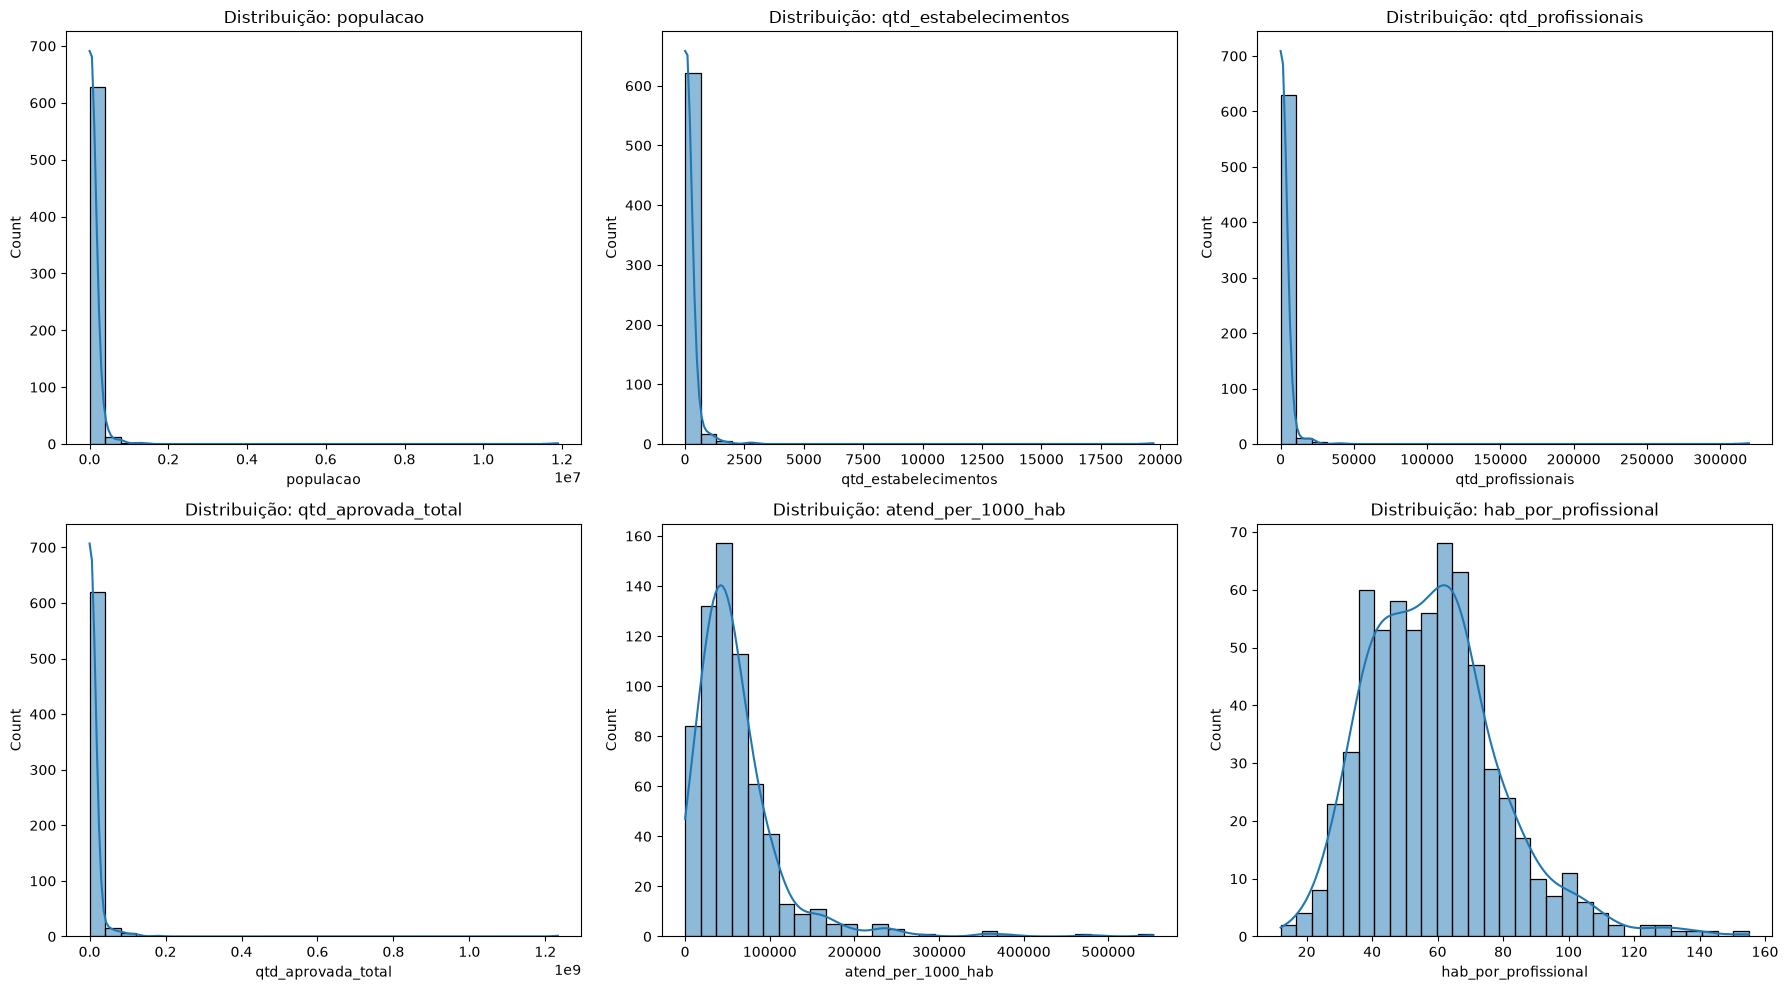

In [36]:

# ============================================================
# CÉLULA 11 - Distribuições (histogramas) das variáveis principais
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
variaveis_plot = ['populacao', 'qtd_estabelecimentos', 'qtd_profissionais',
                   'qtd_aprovada_total', 'atend_per_1000_hab', 'hab_por_profissional']

for ax, col in zip(axes.flatten(), variaveis_plot):
    sns.histplot(df_final[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribuição: {col}')

plt.tight_layout()
plt.show()



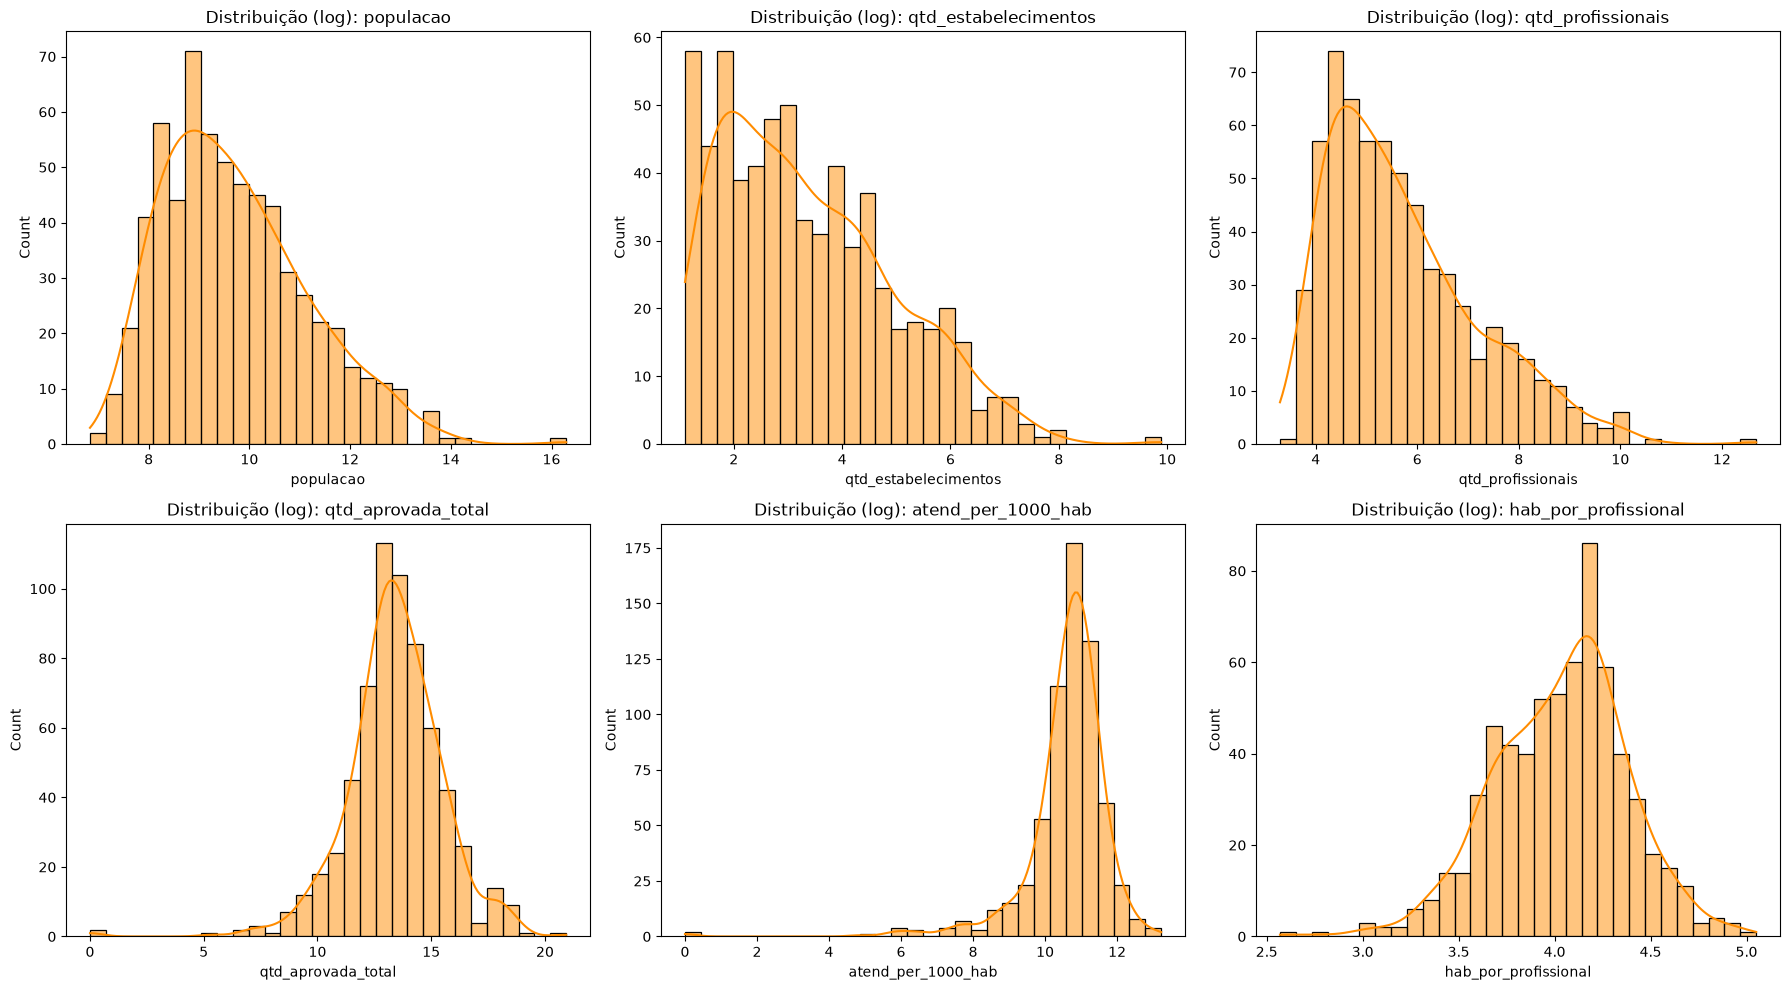

In [37]:
# ============================================================
# CÉLULA 12 - Mesmas distribuições em escala log
# (útil porque população e volume de atendimento são bem
# concentrados em municípios pequenos, com poucos municípios
# grandes puxando a cauda - típico de dados municipais)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), variaveis_plot):
    dados_log = np.log1p(df_final[col])  # log1p evita erro com valores 0
    sns.histplot(dados_log, bins=30, kde=True, ax=ax, color='darkorange')
    ax.set_title(f'Distribuição (log): {col}')

plt.tight_layout()
plt.show()



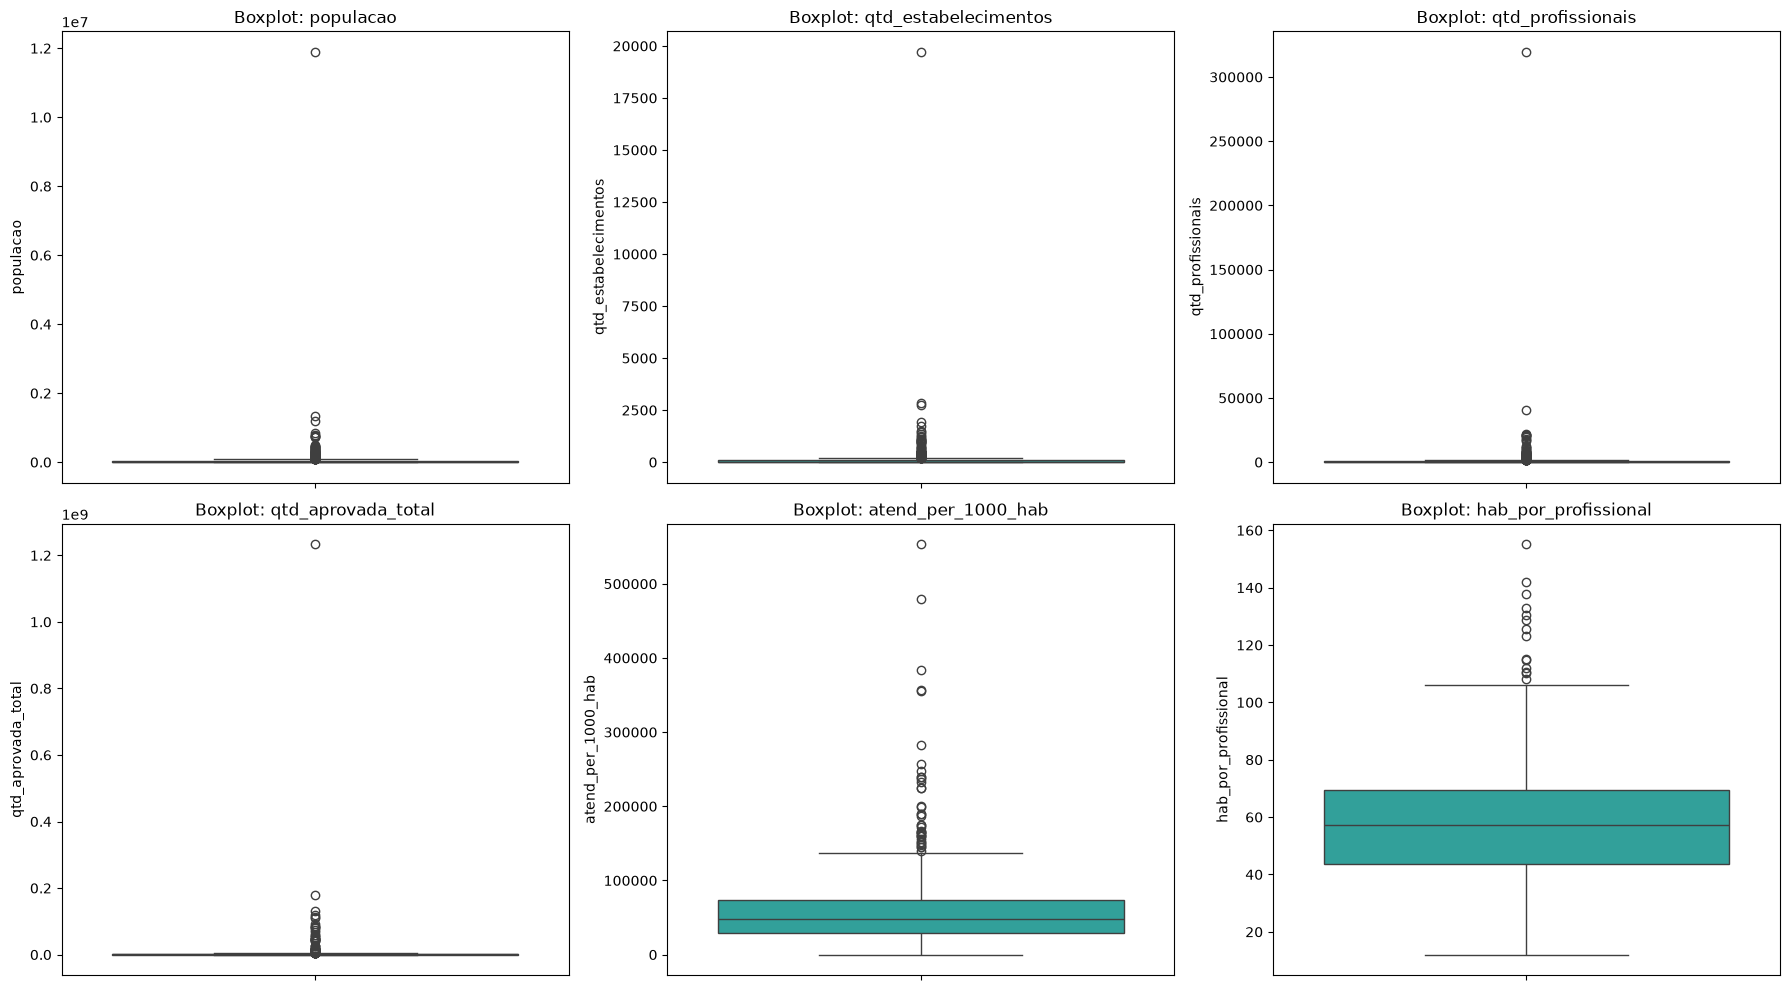

In [38]:

# ============================================================
# CÉLULA 13 - Boxplots para identificar outliers
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), variaveis_plot):
    sns.boxplot(y=df_final[col], ax=ax, color='lightseagreen')
    ax.set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()



In [39]:

# ============================================================
# CÉLULA 14 - Quantificar outliers pelo método IQR
# ============================================================
def contar_outliers_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return ((serie < limite_inferior) | (serie > limite_superior)).sum()

resumo_outliers = pd.DataFrame({
    'coluna': colunas_numericas,
    'qtd_outliers': [contar_outliers_iqr(df_final[c]) for c in colunas_numericas],
    'pct_outliers': [round(contar_outliers_iqr(df_final[c]) / len(df_final) * 100, 1) for c in colunas_numericas]
})
resumo_outliers



,coluna,qtd_outliers,pct_outliers
0,populacao,89,13.8
1,qtd_estabelecimentos,93,14.4
2,total_leitos_clinicos,57,8.8
3,total_leitos_cirurgicos,98,15.2
4,qtd_profissionais,102,15.8
5,carga_horaria_ambulatorial_total,95,14.7
6,qtd_aprovada_total,89,13.8
7,atend_per_1000_hab,38,5.9
8,hab_por_profissional,14,2.2
9,hab_por_estabelecimento,30,4.7


In [40]:

# ============================================================
# CÉLULA 15 - Investigar quem são os outliers (ex: municípios
# com maior população, provavelmente puxando a distribuição)
# ============================================================
top_outliers_populacao = df_final.nlargest(5, 'populacao')[['id_municipio', 'nome_municipio', 'populacao']]
print("Municípios com maior população (prováveis outliers):")
print(top_outliers_populacao)

# Nota: municípios muito grandes (ex: capital) tendem a aparecer
# como outlier em quase todas as variáveis absolutas, simplesmente
# por serem muito maiores que a mediana. Os indicadores derivados
# (atend_per_1000_hab, hab_por_profissional) ajudam a normalizar
# essa diferença de escala entre municípios.



Municípios com maior população (prováveis outliers):
     id_municipio         nome_municipio  populacao
562       3550308              SAO PAULO   11895578
212       3518800              GUARULHOS    1345364
108       3509502               CAMPINAS    1185977
544       3548708  SAO BERNARDO DO CAMPO     840499
534       3547809            SANTO ANDRE     778711


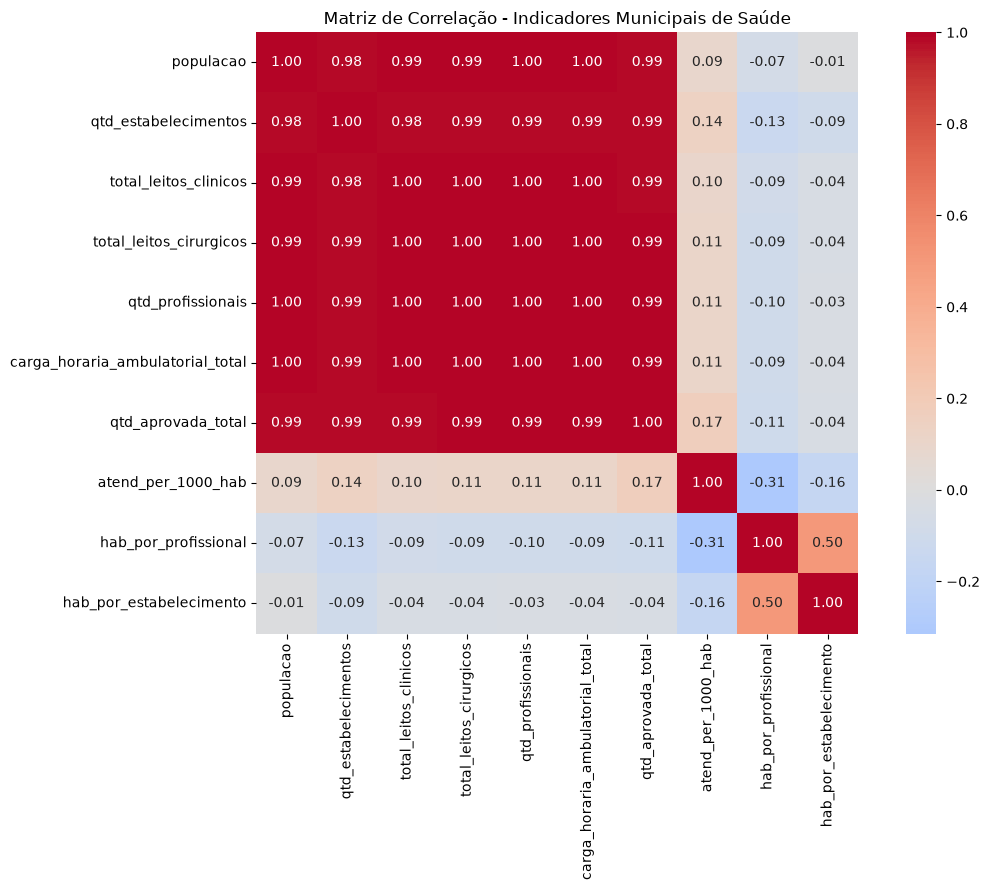

In [41]:

# ============================================================
# CÉLULA 16 - Matriz de correlação
# ============================================================
matriz_corr = df_final[colunas_numericas].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlação - Indicadores Municipais de Saúde')
plt.tight_layout()
plt.show()



Principais observações da matriz de correlação:

1. população, qtd_estabelecimentos, qtd_profissionais e 
   qtd_aprovada_total têm correlação muito forte entre si (>0.95).
   Isso é esperado: municípios maiores naturalmente têm mais
   estrutura de saúde e mais atendimentos em números absolutos.

2. atend_per_1000_hab (indicador normalizado) tem correlação
   bem mais fraca com população - o que é o comportamento
   desejado, já que esse indicador deve refletir a EFICIÊNCIA
   de cobertura, não o tamanho do município.

3. hab_por_profissional e hab_por_estabelecimento têm correlação
   moderada entre si (~0.50), sugerindo que municípios com poucos
   profissionais por habitante tendem também a ter poucos
   estabelecimentos por habitante - possível indício de regiões
   com dupla carência estrutural, relevante para o proxy de
   abandono que o projeto VERTEX busca identificar.

In [42]:
# ============================================================
# CÉLULA 18 - Análise de Comportamento Temporal (2021-2024)
# Como o SIA (atendimentos) só está disponível como total
# agregado no arquivo do grupo, esta análise usa as bases que
# têm granularidade anual (CNES-ST, CNES-PF, IBGE) para
# observar a evolução da capacidade estrutural frente à
# população ao longo do tempo - complementar ao proxy de
# abandono calculado anteriormente.
# ============================================================
pop_ano = df_ibge.groupby('ano')['populacao'].sum().reset_index()
est_ano = df_cnes_st.groupby('ano')['id_estabelecimento_cnes'].nunique().reset_index(name='qtd_estabelecimentos')
prof_ano = df_cnes_pf.groupby('ano')['quantidade_profissionais'].sum().reset_index()

serie_temporal_sp = pop_ano.merge(est_ano, on='ano').merge(prof_ano, on='ano')
serie_temporal_sp['estab_per_100k_hab'] = (serie_temporal_sp['qtd_estabelecimentos'] / serie_temporal_sp['populacao']) * 100000
serie_temporal_sp['prof_per_1000_hab'] = (serie_temporal_sp['quantidade_profissionais'] / serie_temporal_sp['populacao']) * 1000

serie_temporal_sp



,ano,populacao,qtd_estabelecimentos,quantidade_profissionais,estab_per_100k_hab,prof_per_1000_hab
0,2021,46649132,74005,908567,158.641751,19.476611
1,2022,44411238,80394,968881,181.021749,21.816122
2,2023,44411238,85574,1006170,192.685464,22.655752
3,2024,45973194,91079,1066254,198.113274,23.192950


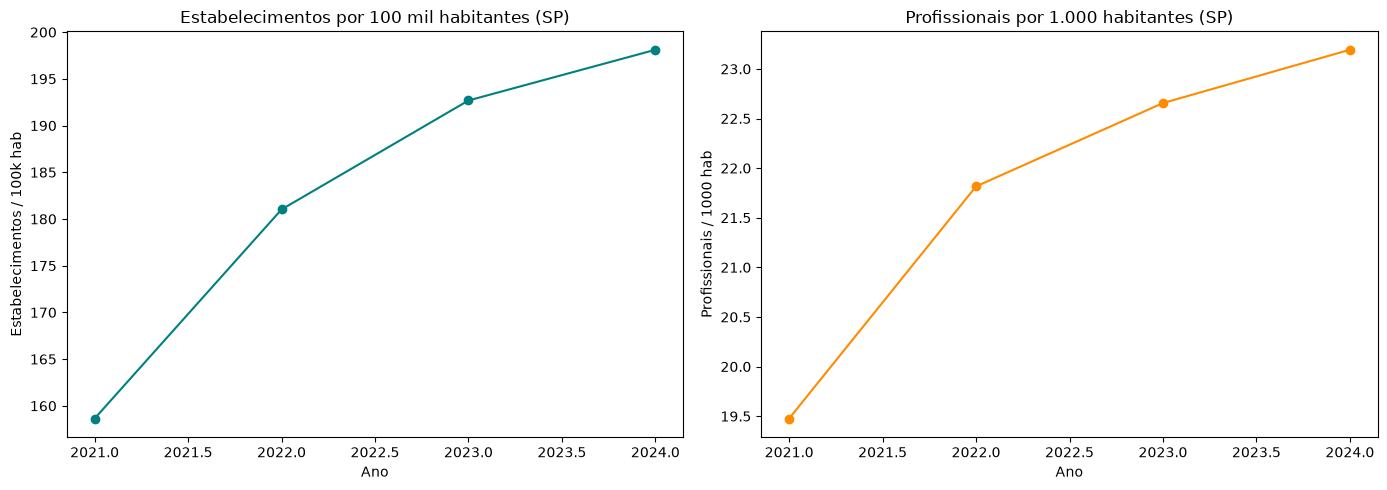

In [43]:

# ============================================================
# CÉLULA 19 - Visualizar a evolução temporal (nível estadual)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(serie_temporal_sp['ano'], serie_temporal_sp['estab_per_100k_hab'], marker='o', color='teal')
axes[0].set_title('Estabelecimentos por 100 mil habitantes (SP)')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Estabelecimentos / 100k hab')

axes[1].plot(serie_temporal_sp['ano'], serie_temporal_sp['prof_per_1000_hab'], marker='o', color='darkorange')
axes[1].set_title('Profissionais por 1.000 habitantes (SP)')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Profissionais / 1000 hab')

plt.tight_layout()
plt.show()


In [44]:

# ============================================================
# CÉLULA 20 - Variação percentual 2021 -> 2024 (nível estadual)
# ============================================================
print("Variação percentual 2021 -> 2024 (Estado de São Paulo):\n")
for col in ['populacao', 'qtd_estabelecimentos', 'quantidade_profissionais',
            'estab_per_100k_hab', 'prof_per_1000_hab']:
    v0 = serie_temporal_sp[serie_temporal_sp['ano'] == 2021][col].values[0]
    v1 = serie_temporal_sp[serie_temporal_sp['ano'] == 2024][col].values[0]
    variacao = (v1 / v0 - 1) * 100
    print(f"{col}: {variacao:+.1f}%")

# Nota: no agregado estadual, a capacidade estrutural (estabelecimentos
# e profissionais por habitante) cresceu proporcionalmente mais que a
# população entre 2021 e 2024 - resultado que vale ser reportado de
# forma honesta, mesmo não confirmando uma hipótese de piora geral.
# O padrão de subutilização/abandono, portanto, não é um fenômeno
# uniforme no estado - ele se concentra em municípios específicos,
# como investigado a seguir.


Variação percentual 2021 -> 2024 (Estado de São Paulo):

populacao: -1.4%
qtd_estabelecimentos: +23.1%
quantidade_profissionais: +17.4%
estab_per_100k_hab: +24.9%
prof_per_1000_hab: +19.1%


In [45]:

# ============================================================
# CÉLULA 21 - Identificar municípios com PIORA na cobertura
# relativa (queda de estabelecimentos por habitante 2021->2024)
# Estes são os municípios mais relevantes para o proxy de
# subutilização/abandono do projeto VERTEX.
# ============================================================
est_mun_ano = df_cnes_st.groupby(['ano', 'id_municipio'])['id_estabelecimento_cnes'] \
    .nunique().reset_index(name='qtd_estabelecimentos')

evolucao_municipal = est_mun_ano.merge(
    df_ibge[['ano', 'id_municipio', 'populacao']], on=['ano', 'id_municipio']
)
evolucao_municipal['estab_per_100k'] = (
    evolucao_municipal['qtd_estabelecimentos'] / evolucao_municipal['populacao']
) * 100000

pivot_temporal = evolucao_municipal.pivot(
    index='id_municipio', columns='ano', values='estab_per_100k'
).dropna(subset=[2021, 2024])

pivot_temporal['variacao_pct_2021_2024'] = (
    pivot_temporal[2024] / pivot_temporal[2021] - 1
) * 100

piores_10 = pivot_temporal.sort_values('variacao_pct_2021_2024').head(10)
piores_10 = piores_10.merge(
    df_final[['id_municipio', 'nome_municipio']].drop_duplicates(),
    left_index=True, right_on='id_municipio', how='left'
)

print("Top 10 municípios com maior queda de cobertura estrutural (2021->2024):")
piores_10[['id_municipio', 'nome_municipio', 2021, 2024, 'variacao_pct_2021_2024']]


Top 10 municípios com maior queda de cobertura estrutural (2021->2024):


,id_municipio,nome_municipio,2021,2024,variacao_pct_2021_2024
154,3513900,DIVINOLANDIA,281.128140,123.740498,-55.984307
31,3502804,ARACATUBA,427.187390,245.457827,-42.540947
242,3521150,IPIGUA,71.981285,42.631803,-40.773767
515,3546108,SANTA CLARA D'OESTE,236.854571,149.420994,-36.914456
1,3500204,ADOLFO,169.252468,111.656990,-34.029329
184,3516101,FLORINEA,266.058533,175.570604,-34.010534
403,3535903,PARANAPUA,72.957198,48.649964,-33.317117
128,3511300,CEDRAL,201.015658,136.778116,-31.956487
460,3541059,PRATANIA,111.711041,76.248570,-31.744821
181,3515806,FLORA RICA,286.327845,201.072386,-29.775469


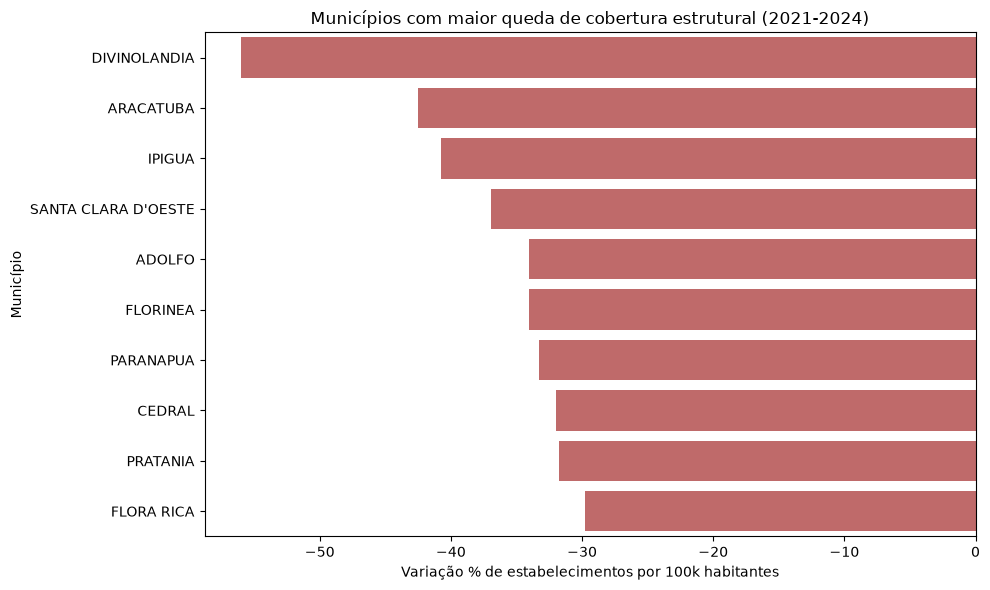

In [46]:

# ============================================================
# CÉLULA 22 - Visualizar os 10 municípios com maior queda
# ============================================================
plt.figure(figsize=(10, 6))
sns.barplot(
    data=piores_10.sort_values('variacao_pct_2021_2024'),
    y='nome_municipio', x='variacao_pct_2021_2024', color='indianred'
)
plt.title('Municípios com maior queda de cobertura estrutural (2021-2024)')
plt.xlabel('Variação % de estabelecimentos por 100k habitantes')
plt.ylabel('Município')
plt.tight_layout()
plt.show()

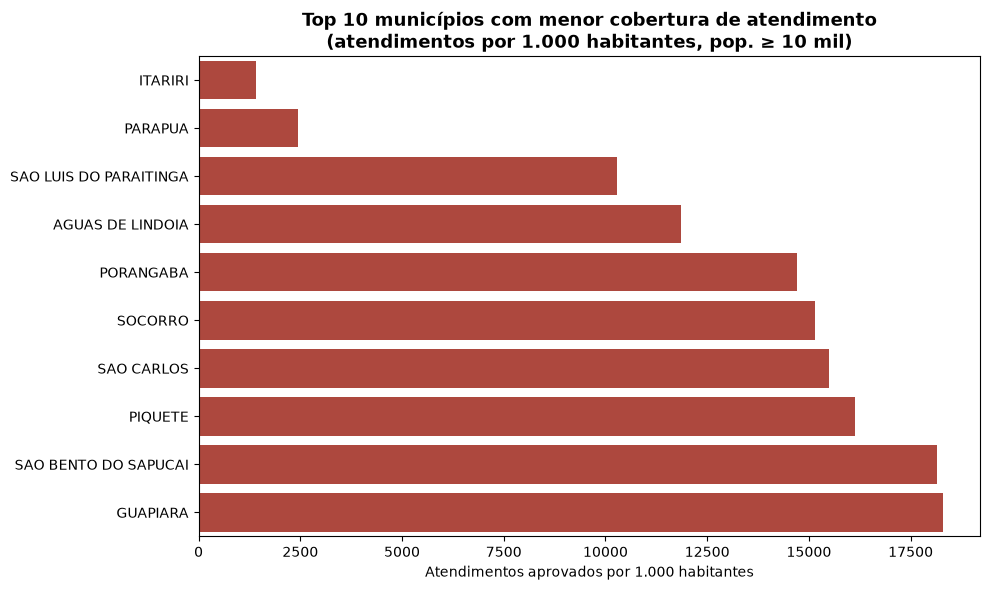

Destaque: Itariri e Parapuã aparecem MUITO abaixo dos demais
(1.409 e 2.438 atendimentos/1000 hab, contra 10.000+ dos outros da lista)
- são os casos mais extremos de sub-cobertura de atendimento no estado.


In [47]:
import os
os.makedirs('graficos_destaque', exist_ok=True)
# ============================================================
# CÉLULA 23 - INSIGHT DE DESTAQUE 1
# Ranking dos municípios com menor cobertura de atendimento
# (filtrando população >= 10 mil para evitar ruído estatístico
# de municípios muito pequenos, onde poucos atendimentos geram
# taxas per capita instáveis)
# ============================================================
df_relevantes = df_final[df_final['populacao'] >= 10000]
piores_atend = df_relevantes.nsmallest(10, 'atend_per_1000_hab').sort_values('atend_per_1000_hab')
 
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=piores_atend, y='nome_municipio', x='atend_per_1000_hab', color='#c0392b', ax=ax)
ax.set_title('Top 10 municípios com menor cobertura de atendimento\n(atendimentos por 1.000 habitantes, pop. ≥ 10 mil)',
              fontsize=13, fontweight='bold')
ax.set_xlabel('Atendimentos aprovados por 1.000 habitantes')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('graficos_destaque/insight1_menor_cobertura.png', dpi=150)
plt.show()
 
print("Destaque: Itariri e Parapuã aparecem MUITO abaixo dos demais")
print("(1.409 e 2.438 atendimentos/1000 hab, contra 10.000+ dos outros da lista)")
print("- são os casos mais extremos de sub-cobertura de atendimento no estado.")


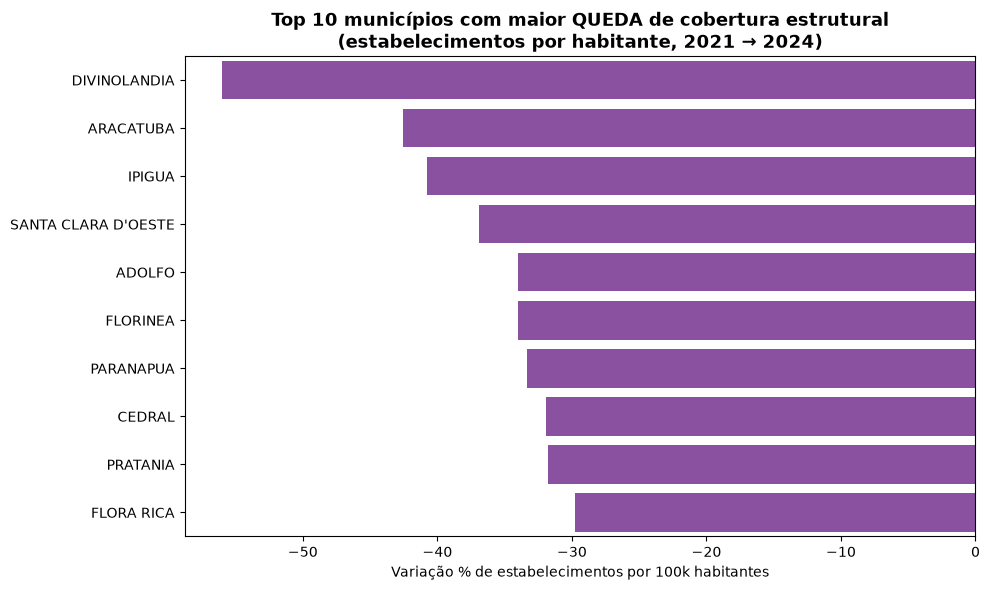

Destaque: enquanto o estado de SP no geral MELHOROU a cobertura estrutural
nesse período (+25%), esses 10 municípios foram na contramão -
alguns com queda de até 55%. São os candidatos mais fortes ao proxy de abandono.


In [48]:

# ============================================================
# CÉLULA 24 - INSIGHT DE DESTAQUE 2
# Municípios que pioraram a cobertura estrutural (2021-2024)
# (reaproveita a análise temporal já feita nas células 18-22)
# ============================================================
# já temos "piores_10" calculado nas células anteriores - reexibindo
# o gráfico como peça de destaque, com salvamento em arquivo
 
plt.figure(figsize=(10, 6))
sns.barplot(
    data=piores_10.sort_values('variacao_pct_2021_2024'),
    y='nome_municipio', x='variacao_pct_2021_2024', color='#8e44ad'
)
plt.title('Top 10 municípios com maior QUEDA de cobertura estrutural\n(estabelecimentos por habitante, 2021 → 2024)',
          fontsize=13, fontweight='bold')
plt.xlabel('Variação % de estabelecimentos por 100k habitantes')
plt.ylabel('')
plt.tight_layout()
plt.savefig('graficos_destaque/insight2_queda_cobertura.png', dpi=150)
plt.show()
 
print("Destaque: enquanto o estado de SP no geral MELHOROU a cobertura estrutural")
print("nesse período (+25%), esses 10 municípios foram na contramão -")
print("alguns com queda de até 55%. São os candidatos mais fortes ao proxy de abandono.")


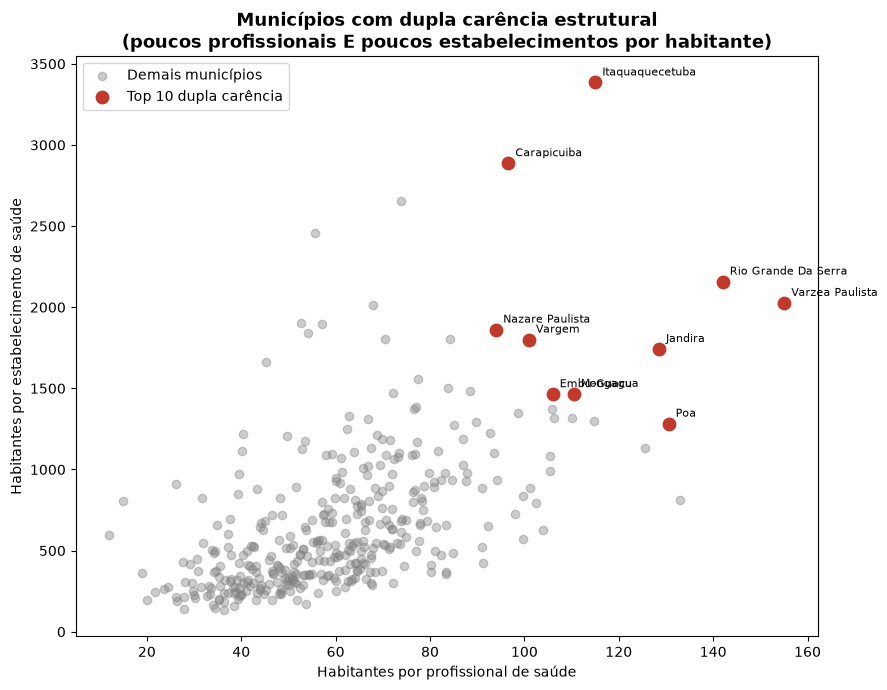

Destaque: cluster nítido de municípios da periferia da Grande São Paulo
(Itaquaquecetuba, Carapicuíba, Jandira, Várzea Paulista, Poá) com carência
simultânea de profissionais E estrutura física - maior risco de abandono.


In [49]:

# ============================================================
# CÉLULA 25 - INSIGHT DE DESTAQUE 3
# Municípios com "dupla carência" (poucos profissionais E
# poucos estabelecimentos por habitante, simultaneamente)
# ============================================================
df_rel2 = df_final[df_final['populacao'] >= 10000].copy()
df_rel2['score_carencia'] = df_rel2['hab_por_profissional'].rank(pct=True) + df_rel2['hab_por_estabelecimento'].rank(pct=True)
top10_carencia = df_rel2.nlargest(10, 'score_carencia')
 
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df_rel2['hab_por_profissional'], df_rel2['hab_por_estabelecimento'],
           alpha=0.4, color='gray', label='Demais municípios')
ax.scatter(top10_carencia['hab_por_profissional'], top10_carencia['hab_por_estabelecimento'],
           color='#c0392b', s=80, label='Top 10 dupla carência')
for _, row in top10_carencia.iterrows():
    ax.annotate(row['nome_municipio'].title(),
                (row['hab_por_profissional'], row['hab_por_estabelecimento']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Habitantes por profissional de saúde')
ax.set_ylabel('Habitantes por estabelecimento de saúde')
ax.set_title('Municípios com dupla carência estrutural\n(poucos profissionais E poucos estabelecimentos por habitante)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graficos_destaque/insight3_dupla_carencia.png', dpi=150)
plt.show()
 
print("Destaque: cluster nítido de municípios da periferia da Grande São Paulo")
print("(Itaquaquecetuba, Carapicuíba, Jandira, Várzea Paulista, Poá) com carência")
print("simultânea de profissionais E estrutura física - maior risco de abandono.")
 

In [ ]:

# ============================================================
# CÉLULA 26 - Exportar tabelas de ranking para o dashboard
# ============================================================

import os
os.makedirs('graficos_destaque', exist_ok=True)
 
piores_atend.to_csv('graficos_destaque/ranking_menor_cobertura.csv', index=False)
piores_10.to_csv('graficos_destaque/ranking_queda_estrutural.csv', index=False)
top10_carencia.to_csv('graficos_destaque/ranking_dupla_carencia.csv', index=False)
 
print("3 gráficos (.png) e 3 tabelas de ranking (.csv) exportados na pasta 'graficos_destaque/'")

3 gráficos (.png) e 3 tabelas de ranking (.csv) exportados na pasta 'graficos_destaque/'
